<a href="https://colab.research.google.com/github/nozanin-13/ML-Begin/blob/main/%D0%A3%D1%80%D0%BE%D0%BA11_%D1%81%D0%B0%D0%BC%D0%BE%D1%81%D1%82%D0%BE%D1%8F%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Урок 11 — Самостоятельная работа: Метрики и матрица ошибок

### Как работать
Читай теорию · запускай код по порядку · выполняй задания 📝 · отвечай словами ✍️.

> 🎯 **К концу урока ты сможешь:** объяснить, почему accuracy иногда врёт, прочитать матрицу ошибок и понять, чем precision отличается от recall.

Устанавливать ничего не нужно — всё есть в Colab. 🚀

## Шаг 0 · Обучаем модель
Берём знакомый Titanic и лес в Pipeline (с урока 10). Просто запусти.

In [1]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

num = ['age','fare','sibsp','parch']; cat = ['sex','pclass','embarked']
prep = ColumnTransformer([
    ('num', Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())]), num),
    ('cat', Pipeline([('i',SimpleImputer(strategy='most_frequent')),('o',OneHotEncoder(handle_unknown='ignore'))]), cat),
])

df = sns.load_dataset('titanic')
X = df[num+cat]; y = df['survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = Pipeline([('prep',prep),('forest',RandomForestClassifier(n_estimators=100,random_state=42))])
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print('Готово! Модель обучена.')

Готово! Модель обучена.


## Шаг 1 · Провокация: 99% и бесполезно
Представь модель, которая ВСЕГДА говорит «погиб». Посмотри на её accuracy и recall.

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dp = dummy.predict(X_test)
print(f'accuracy = {accuracy_score(y_test,dp):.0%}')
print(f'recall   = {recall_score(y_test,dp):.0%}   <- скольких выживших поймала')

accuracy = 59%
recall   = 0%   <- скольких выживших поймала


✍️ **Ответь словами.** Accuracy неплохая, а recall = 0. Почему такая модель бесполезна?

*Твой ответ:* …может что то тпропустили при запуске и recall не сработал

## Шаг 2 · Матрица ошибок
Четыре клетки: верные ответы на диагонали, ошибки — вне неё.

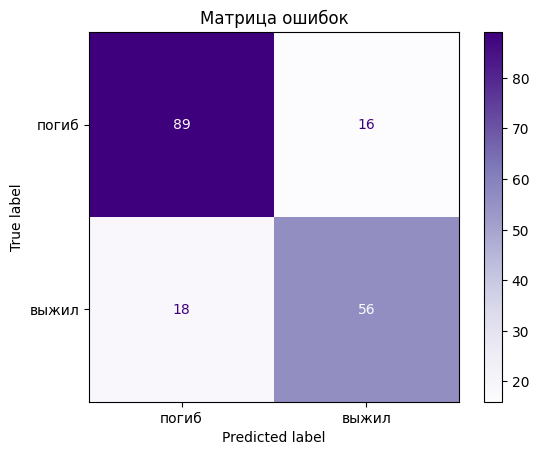

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['погиб','выжил'], cmap='Purples')
plt.title('Матрица ошибок'); plt.show()

✍️ **Вопрос .** Сколько выживших модель ошибочно посчитала погибшими (пропуски)? Найди клетку на картинке.

*Твой ответ:* ошибочно 18…

## Шаг 3 · Precision и Recall
Полный отчёт по метрикам.

In [4]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['погиб','выжил']))

              precision    recall  f1-score   support

       погиб       0.83      0.85      0.84       105
       выжил       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



**Как читать (для класса «выжил»):**
- **precision** — из тех, кого назвали «выжил», сколько реально выжили;
- **recall** — из всех выживших скольких поймали;
- **f1** — компромисс между ними.

### 📝 Задание — порог решения
Меняй `thr` (0.3, 0.5, 0.7) и запускай. Заметь: ниже порог → больше recall, но меньше precision.

In [8]:
from sklearn.metrics import precision_score, recall_score
proba = model.predict_proba(X_test)[:,1]

thr = 0.7   # 👈 МЕНЯЙ (0.3, 0.5, 0.7)
pred = (proba >= thr).astype(int)
print(f'порог {thr}:  precision={precision_score(y_test,pred):.0%}  recall={recall_score(y_test,pred):.0%}')

порог 0.7:  precision=86%  recall=69%


## ✅ Проверь себя
1. Когда accuracy обманывает?
2. Чем precision отличается от recall?
3. Для детектора болезни что важнее?

<details><summary>Ответы</summary>

1. Когда одного класса намного больше — можно получить высокую accuracy, ничего не найдя.
2. precision — из названных «да» сколько верно; recall — из всех «да» скольких нашли.
3. Recall (нельзя пропустить больного).
</details>

## 🏁 Финальное задание (3 уровня)
**Базовый.** Выведи матрицу ошибок и classification_report для модели.
**Средний.** Определи, какая метрика важнее для «предсказать выжившего», и обоснуй.
**Продвинутый.** Найди порог, при котором recall ≥ 0.85, и посмотри, что стало с precision.

In [11]:
# Продвинутый (стартер) — ищем порог под recall >= 0.85
from sklearn.metrics import precision_score, recall_score
proba = model.predict_proba(X_test)[:,1]
for thr in [0.5, 0.4, 0.3, 0.2 ,0.1, 0.6, 0.7,]:
    pred = (proba >= thr).astype(int)
    r = recall_score(y_test, pred); p = precision_score(y_test, pred)
    print(f'порог {thr}: recall={r:.0%} precision={p:.0%}')

порог 0.5: recall=77% precision=78%
порог 0.4: recall=81% precision=73%
порог 0.3: recall=88% precision=71%
порог 0.2: recall=92% precision=66%
порог 0.1: recall=93% precision=57%
порог 0.6: recall=72% precision=83%
порог 0.7: recall=69% precision=86%
порог 0: recall=100% precision=41%
порог 8: recall=0% precision=0%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---
### 🎉 Готово!
Теперь ты умеешь оценивать модель честно. На следующем уроке — твой собственный мини-проект!